In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from ixplore import IXPLORE
from ixplore.utils import compute_rasch_values
from ixplore.visualization import plot_embedding, plot_posterior, clean_axis, colormap

# Sampling in IXPLORE: Rasch vs Posterior

This notebook compares two sampling strategies for generating pseudo-answers for a **new user** 
who has answered only 8 out of 70 items from a Likert-scale questionnaire:

1. **Rasch sampling** — uses the Rasch model's category response functions (normal PDFs centred at each answer option) 
   applied to the user's *imputed* continuous scores, then draws discrete samples via the Gumbel-max trick.
2. **Posterior sampling** — computes the full Bayesian posterior over the 2D latent space given the observed answers, 
   samples latent positions from that posterior, and predicts continuous probabilities from each sampled position.

All accuracy metrics (MAE) are computed **only on unobserved items** — the items the user has 
*not* answered — giving an honest measure of generalisation. The figures show all items 
(with observed items highlighted) to give full context.

A **random baseline** (uniform sampling) is included for reference. We use a **pretrained 
model** (item parameters + user embeddings fitted on 250 users) so that the new user is 
evaluated against an already-calibrated item landscape.

In [2]:
# Load the full dataset and pretrained model artifacts
reactions = pd.read_csv('../data/likert_reactions.csv', index_col=0)
pretrained_embedding = pd.read_csv('../data/pretrained_embedding_likert.csv', index_col=0)
pretrained_models = pd.read_csv('../data/pretrained_models_likert.csv', index_col=0)

print(f"Dataset: {reactions.shape[0]} users, {reactions.shape[1]} items")
print(f"Answer range: {reactions.min().min()} – {reactions.max().max()}")
reactions.head(3)

Dataset: 250 users, 70 items
Answer range: 0 – 3


,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,Q61,Q62,Q63,Q64,Q65,Q66,Q67,Q68,Q69,Q70
id,,,,,,,,,,,,,,,,,,,,,
0,1,2,3,0,3,1,2,3,2,3,...,0,2,2,1,2,2,3,1,2,2
1,1,2,3,0,3,1,2,3,2,3,...,0,2,2,1,2,2,3,1,2,2
2,1,2,3,0,3,1,1,2,2,3,...,0,2,2,1,2,2,3,1,2,2


In [3]:
# Initialize the model with pretrained parameters (no re-fitting needed)
xplore = IXPLORE(
    reactions=reactions,
    pretrained_embedding=pretrained_embedding,
    pretrained_models=pretrained_models,
)

ixplore - INFO - 2026-03-14 10:56:32 - Number of users for model: 250
ixplore - INFO - 2026-03-14 10:56:32 - Number of items: 70
ixplore - INFO - 2026-03-14 10:56:32 - Number of missing values: 0 (0.00%)
ixplore - INFO - 2026-03-14 10:56:32 - Grid created with resolution 200x200, total 40000 points
ixplore - INFO - 2026-03-14 10:56:32 - Prior set with mean [0 0] and covariance [1 0 0 1]
ixplore - INFO - 2026-03-14 10:56:32 - Random state set to 0
ixplore - INFO - 2026-03-14 10:56:32 - Used pretrained embedding.
ixplore - INFO - 2026-03-14 10:56:32 - Used pretrained model parameters.


## Simulate a New User with Partial Answers

We pick an existing user as ground truth and reveal the **first 8** out of 70 items.
This mimics a cold-start scenario where a new user has answered only a handful of questions.

In [4]:
# Ground truth: user 0's full answers (scaled to [0,1] by the model)
ground_truth_user = '0'
n_observed = 8

# Get the user's true (scaled) answers for all items
true_answers_scaled = pd.Series(
    xplore.reactions[xplore.users.get_loc(ground_truth_user)],
    index=xplore.items,
    name=ground_truth_user,
)

# Simulate partial observation: reveal the first n_observed items
observed_items = xplore.items[:n_observed]
partial_answers = true_answers_scaled[observed_items]

print(f"User {ground_truth_user} — observed {n_observed} / {len(xplore.items)} items:")
for item, val in partial_answers.items():
    raw_val = reactions.loc[int(ground_truth_user), item]
    print(f"  {item}: {raw_val} (raw)  →  {val:.3f} (scaled)")

User 0 — observed 8 / 70 items:
  Q1: 1 (raw)  →  0.333 (scaled)
  Q2: 2 (raw)  →  0.667 (scaled)
  Q3: 3 (raw)  →  1.000 (scaled)
  Q4: 0 (raw)  →  0.000 (scaled)
  Q5: 3 (raw)  →  1.000 (scaled)
  Q6: 1 (raw)  →  0.333 (scaled)
  Q7: 2 (raw)  →  0.667 (scaled)
  Q8: 3 (raw)  →  1.000 (scaled)


## 1. Rasch Sampling (Category Response Functions)

The Rasch method works in **answer space** rather than latent space:

1. **Impute** all missing answers using Bayesian marginalisation (`predict_all_answers`), 
   producing a continuous score in [0, 1] for every item.
2. For each item, evaluate **normal PDFs** centred at each discrete answer option 
   (e.g. 0, 0.33, 0.67, 1.0 for a 4-point Likert scale) and normalise to get 
   category probabilities — these are the **Category Response Functions (CRFs)**.
3. Draw discrete category samples using the **Gumbel-max trick** 
   (equivalent to sampling from a categorical distribution, but vectorised).

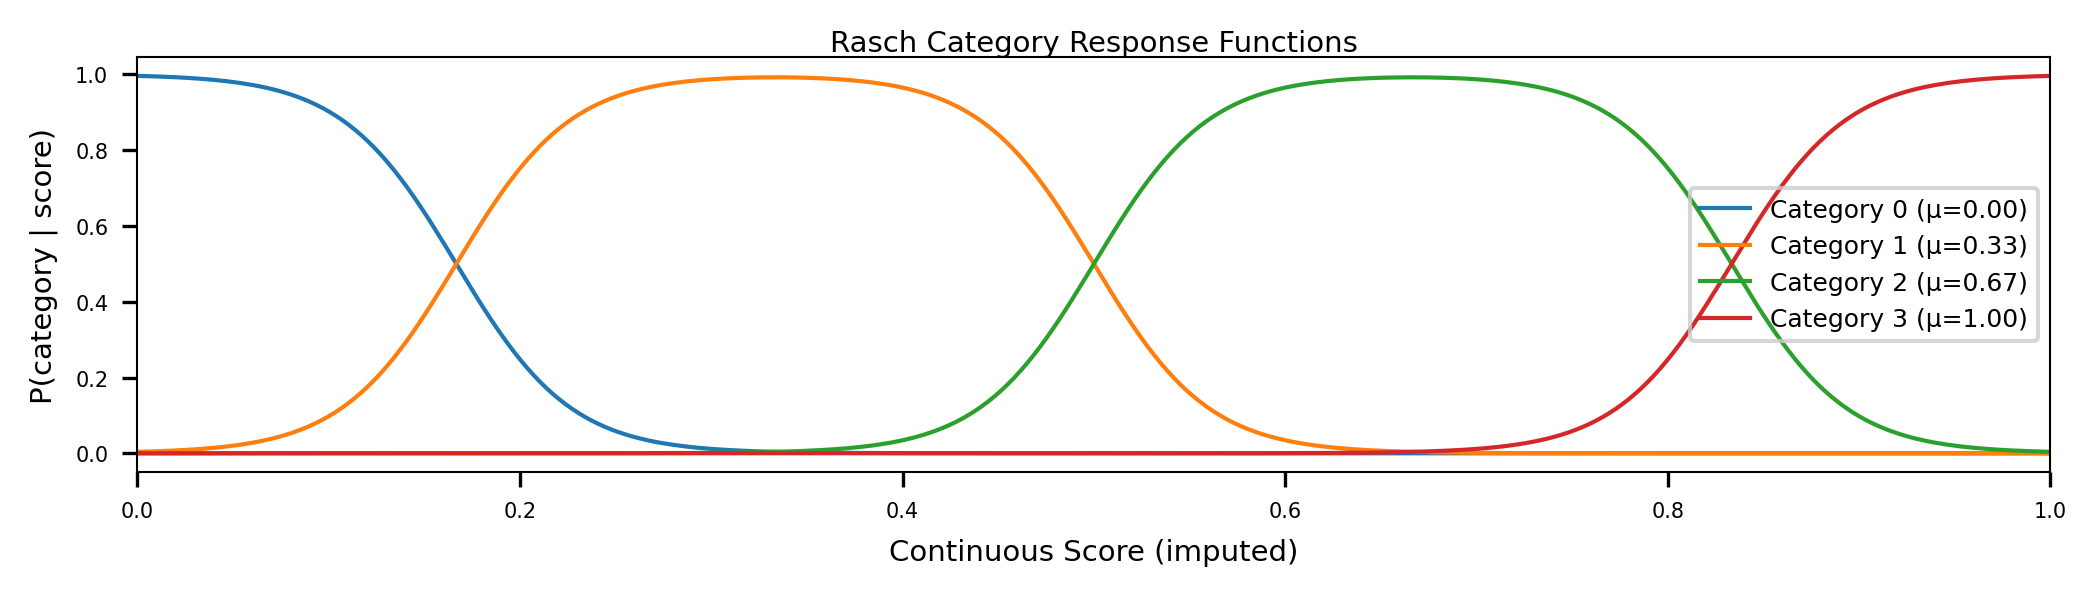

In [5]:
# Visualise the Category Response Functions for different score levels
num_options = 4
variance = 0.1
theta = np.linspace(0, 1, 300)

probs, answer_options = compute_rasch_values(theta, num_options, variance)

fig, ax = plt.subplots(figsize=(7, 2))
for i, mu in enumerate(answer_options):
    ax.plot(theta, probs[i], label=f'Category {i} (μ={mu:.2f})')
ax.set(xlabel='Continuous Score (imputed)', ylabel='P(category | score)',
       title='Rasch Category Response Functions', xlim=(0, 1))
ax.legend(fontsize=6)
plt.tight_layout()
plt.show()

In [6]:
# Draw Rasch samples for the new user
num_samples = 1000
rasch_samples = xplore.sample_pseudo_answers(
    partial_answers, method='rasch', num_samples=num_samples,
    num_options=num_options, variance=variance,
)

# Mask for observed vs unobserved items
obs_mask = np.array([item in observed_items for item in xplore.items])
unobs_mask = ~obs_mask

# Variance comparison (on unobserved items only)
rasch_std = rasch_samples[:, unobs_mask].std(axis=0)
print(f"Rasch sample variance (unobserved items only, n={unobs_mask.sum()}):")
print(f"  mean σ = {rasch_std.mean():.4f}")

Rasch sample variance (unobserved items only, n=62):
  mean σ = 0.0871


## 2. Posterior Sampling (Latent-Space)

The posterior method works in the **2D latent space**:

1. Compute the **posterior distribution** P(position | observed answers) over a fine grid 
   using the likelihood of each grid point and a Gaussian prior.
2. **Sample grid positions** proportional to their posterior probability — positions where the 
   observed answers are most likely get sampled more often.
3. For each sampled position, **predict** continuous answer probabilities for all items 
   using the fitted logistic item parameters.

Because the posterior spreads over a region of latent space (rather than collapsing to a 
single point), this method naturally produces **high-variance samples** — which is a good 
thing. The variance reflects genuine diversity in plausible answer profiles, not noise.

In [7]:
# Draw posterior samples for the new user
posterior_samples = xplore.sample_pseudo_answers(
    partial_answers, method='posterior', num_samples=num_samples,
)
print(f"Posterior samples shape: {posterior_samples.shape}")
print(f"Sample range: [{posterior_samples.min():.4f}, {posterior_samples.max():.4f}]")

Posterior samples shape: (1000, 70)
Sample range: [0.0007, 0.9998]


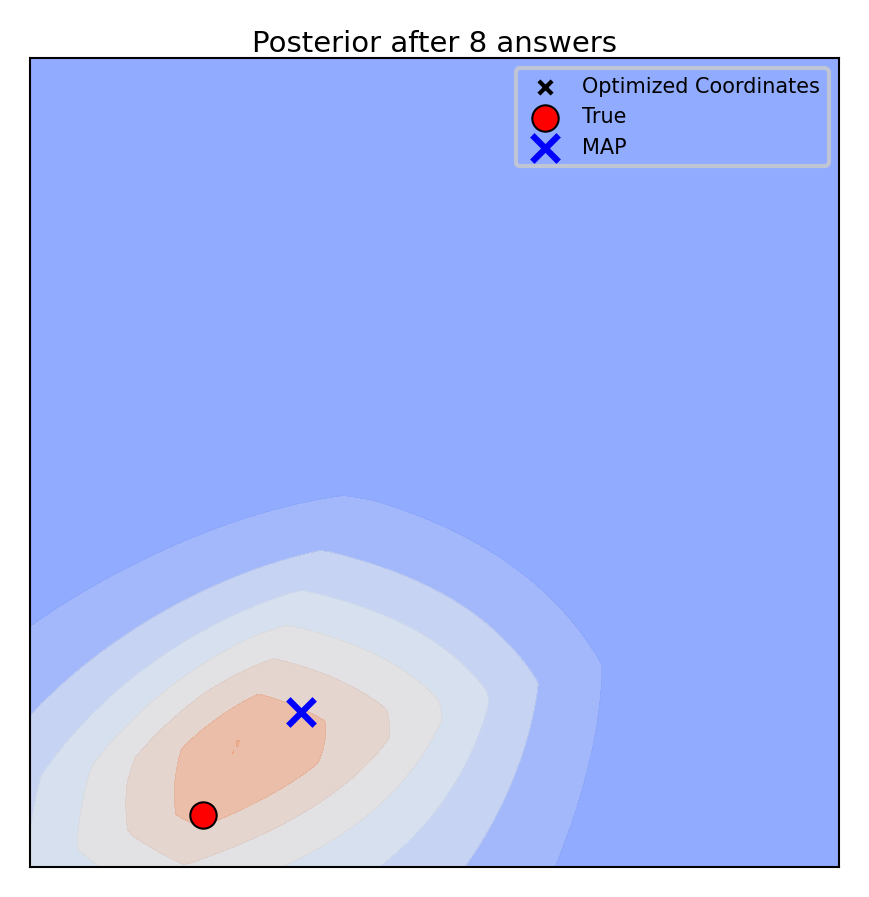

In [8]:
# Posterior distribution for user 0 after 8 answers
fig, ax = plt.subplots(figsize=(3.5, 3))

plot_posterior(xplore, partial_answers, ax=ax, add_bar=False)

embedding_df = xplore.get_embedding()
true_pos = embedding_df.loc[ground_truth_user]
estimated_pos = xplore.embed_new_user(partial_answers)
ax.scatter(true_pos['x'], true_pos['y'], color='red', s=40, zorder=10, edgecolors='black', lw=0.5, label='True')
ax.scatter(estimated_pos[0], estimated_pos[1], marker='x', color='blue', s=40, zorder=10, lw=1.5, label='MAP')
# plot_embedding(xplore.get_embedding(), ax=ax, colors='lightgray', s=20)
ax.legend(fontsize=5)
ax.set_title(f'Posterior after {n_observed} answers', fontsize=7)
clean_axis(ax)

plt.tight_layout()
plt.show()

## 3. Compare Sample Distributions

All MAE and variance metrics below are computed **only on unobserved items**.

### Per-item means: how close are the sample averages to the true answers?

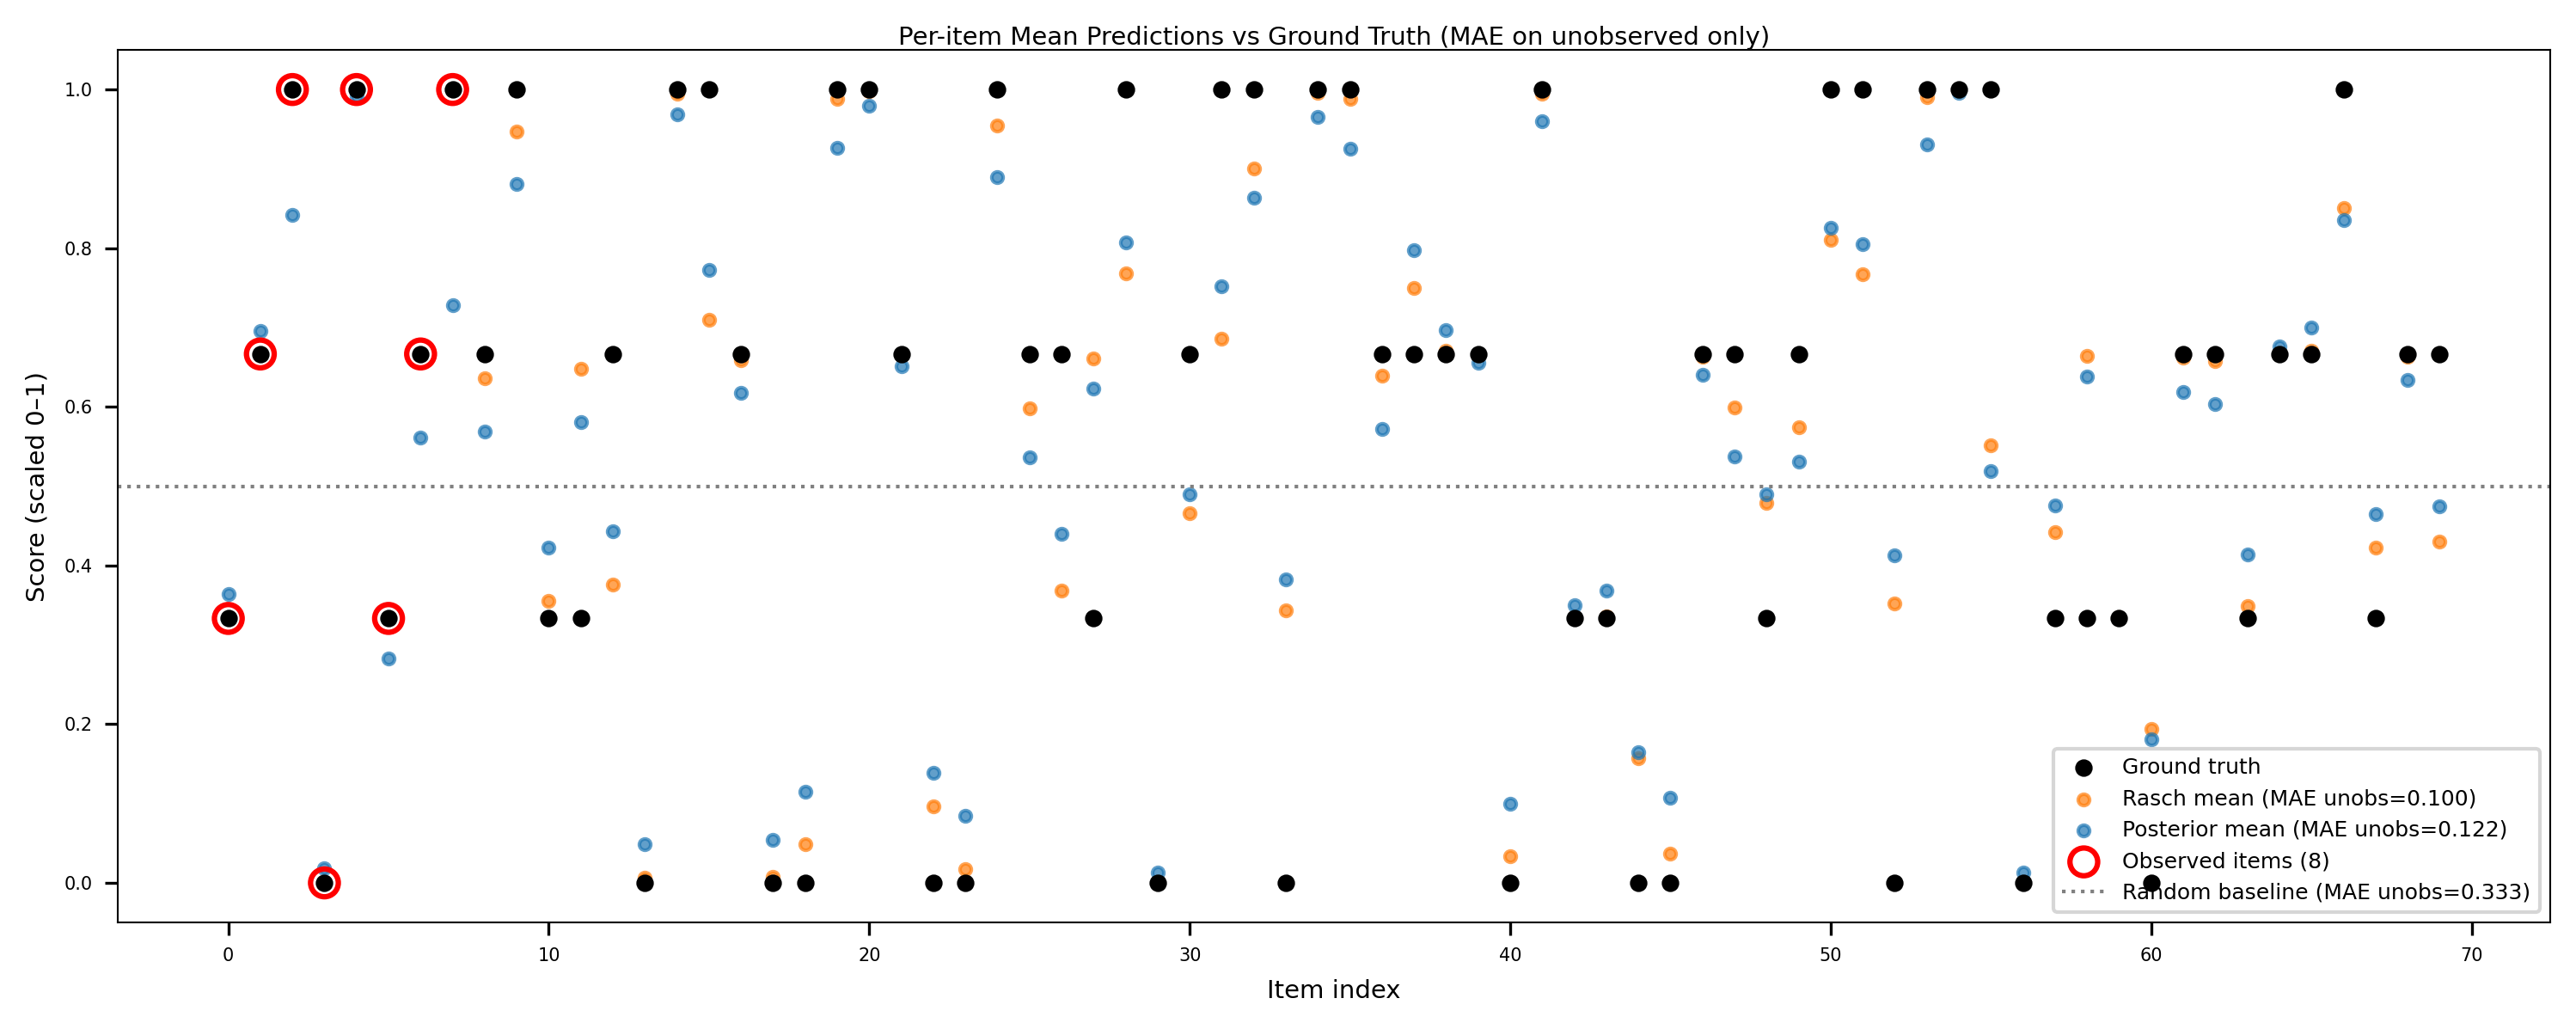

In [9]:
# Compare mean predictions from both methods against ground truth
rasch_mean = rasch_samples.mean(axis=0)
posterior_mean = posterior_samples.mean(axis=0)
true_vals = true_answers_scaled.values
items_idx = np.arange(len(xplore.items))

# MAE only on unobserved items
rasch_mae_unobs = np.mean(np.abs(rasch_mean[unobs_mask] - true_vals[unobs_mask]))
post_mae_unobs = np.mean(np.abs(posterior_mean[unobs_mask] - true_vals[unobs_mask]))
random_mae_unobs = np.mean(np.abs(0.5 - true_vals[unobs_mask]))

fig, ax = plt.subplots(figsize=(10, 4))

ax.scatter(items_idx, true_vals, color='black', s=15, label='Ground truth', zorder=5)
ax.scatter(items_idx, rasch_mean, color='tab:orange', s=10, alpha=0.7, 
           label=f'Rasch mean (MAE unobs={rasch_mae_unobs:.3f})')
ax.scatter(items_idx, posterior_mean, color='tab:blue', s=10, alpha=0.7, 
           label=f'Posterior mean (MAE unobs={post_mae_unobs:.3f})')

# Highlight observed items
obs_idx = [list(xplore.items).index(item) for item in observed_items]
ax.scatter(obs_idx, true_vals[obs_idx], edgecolors='red', facecolors='none', 
           s=60, lw=1.5, label=f'Observed items ({n_observed})', zorder=6)

# Random baseline as horizontal reference
ax.axhline(0.5, color='gray', ls=':', lw=1, label=f'Random baseline (MAE unobs={random_mae_unobs:.3f})')

ax.set(xlabel='Item index', ylabel='Score (scaled 0–1)', 
       title='Per-item Mean Predictions vs Ground Truth (MAE on unobserved only)')
ax.legend(fontsize=6)
plt.tight_layout()
plt.show()

### Per-item variance across samples

Higher variance in the samples is desirable — it means the method produces **diverse, 
realistic pseudo-answers** that capture the range of plausible responses. A method with 
high accuracy *and* high variance generates samples that are both correct on average 
and rich enough to be useful for downstream tasks (e.g. data augmentation, active learning).

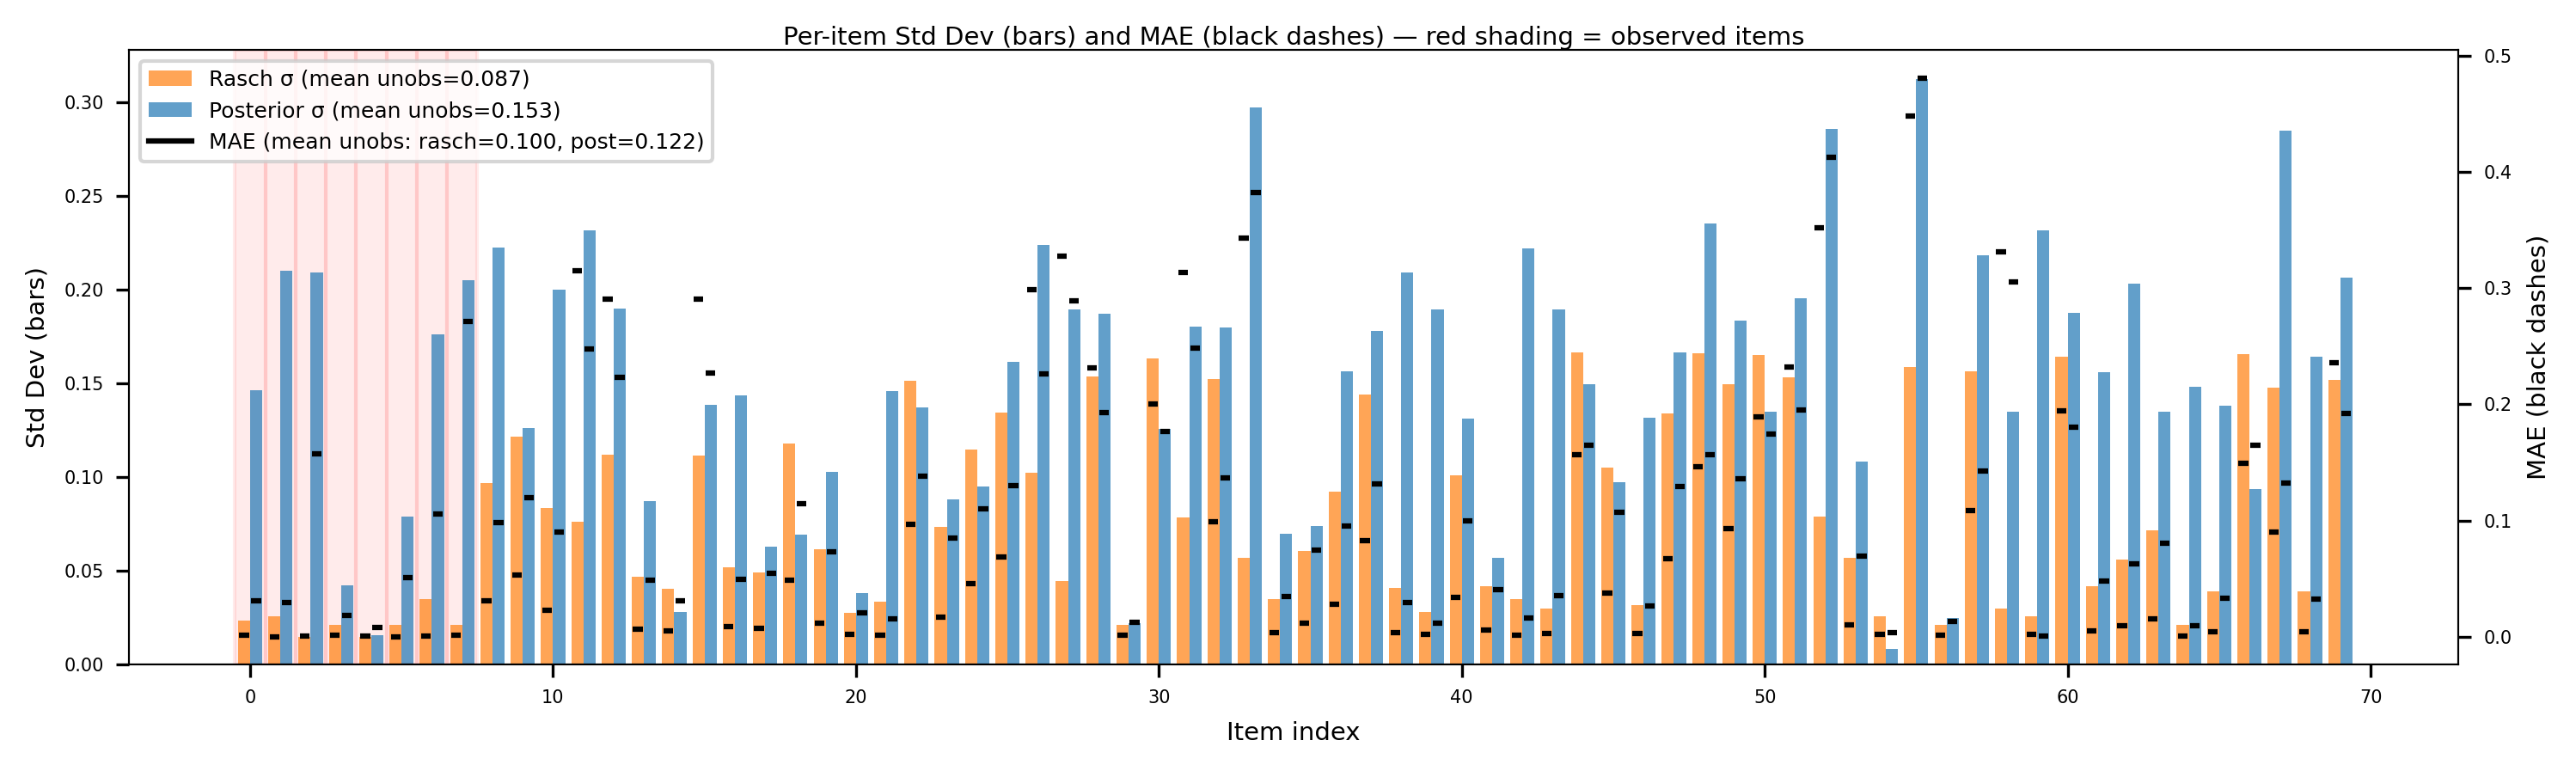

In [18]:
# Compare variance and MAE across ALL items
rasch_std_all = rasch_samples.std(axis=0)
posterior_std_all = posterior_samples.std(axis=0)
rasch_mae_all = np.abs(rasch_samples.mean(axis=0) - true_vals)
posterior_mae_all = np.abs(posterior_samples.mean(axis=0) - true_vals)

fig, ax1 = plt.subplots(figsize=(10, 3))
ax2 = ax1.twinx()

# Std Dev as bars on left y-axis
bar_width = 0.4
ax1.bar(items_idx - 0.2, rasch_std_all, width=bar_width, color='tab:orange', alpha=0.7,
        label=f'Rasch σ (mean unobs={rasch_std_all[unobs_mask].mean():.3f})')
ax1.bar(items_idx + 0.2, posterior_std_all, width=bar_width, color='tab:blue', alpha=0.7,
        label=f'Posterior σ (mean unobs={posterior_std_all[unobs_mask].mean():.3f})')

# Per-item MAE as horizontal black dashes within each bar, plotted on right y-axis
dash_width = bar_width * 0.8
for i in items_idx:
    ax2.plot([i - 0.2 - dash_width/2, i - 0.2 + dash_width/2],
             [rasch_mae_all[i], rasch_mae_all[i]],
             color='black', lw=1.5, solid_capstyle='butt')
    ax2.plot([i + 0.2 - dash_width/2, i + 0.2 + dash_width/2],
             [posterior_mae_all[i], posterior_mae_all[i]],
             color='black', lw=1.5, solid_capstyle='butt')

# Dummy handle for legend
ax2.plot([], [], color='black', lw=1.5,
         label=f'MAE (mean unobs: rasch={rasch_mae_all[unobs_mask].mean():.3f}, post={posterior_mae_all[unobs_mask].mean():.3f})')

# Mark observed items
for i in items_idx[obs_mask]:
    ax1.axvspan(i - 0.5, i + 0.5, color='red', alpha=0.08, zorder=0)

ax1.set_xlabel('Item index')
ax1.set_ylabel('Std Dev (bars)')
ax2.set_ylabel('MAE (black dashes)')
ax1.set_title('Per-item Std Dev (bars) and MAE (black dashes) — red shading = observed items')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
leg = ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=6, loc='upper left')
leg.get_frame().set_facecolor('white')

plt.tight_layout()
plt.show()

### Sample distributions for example items

Top row: observed items. Bottom row: unobserved items. MAE is shown per panel for each 
method and the random baseline.

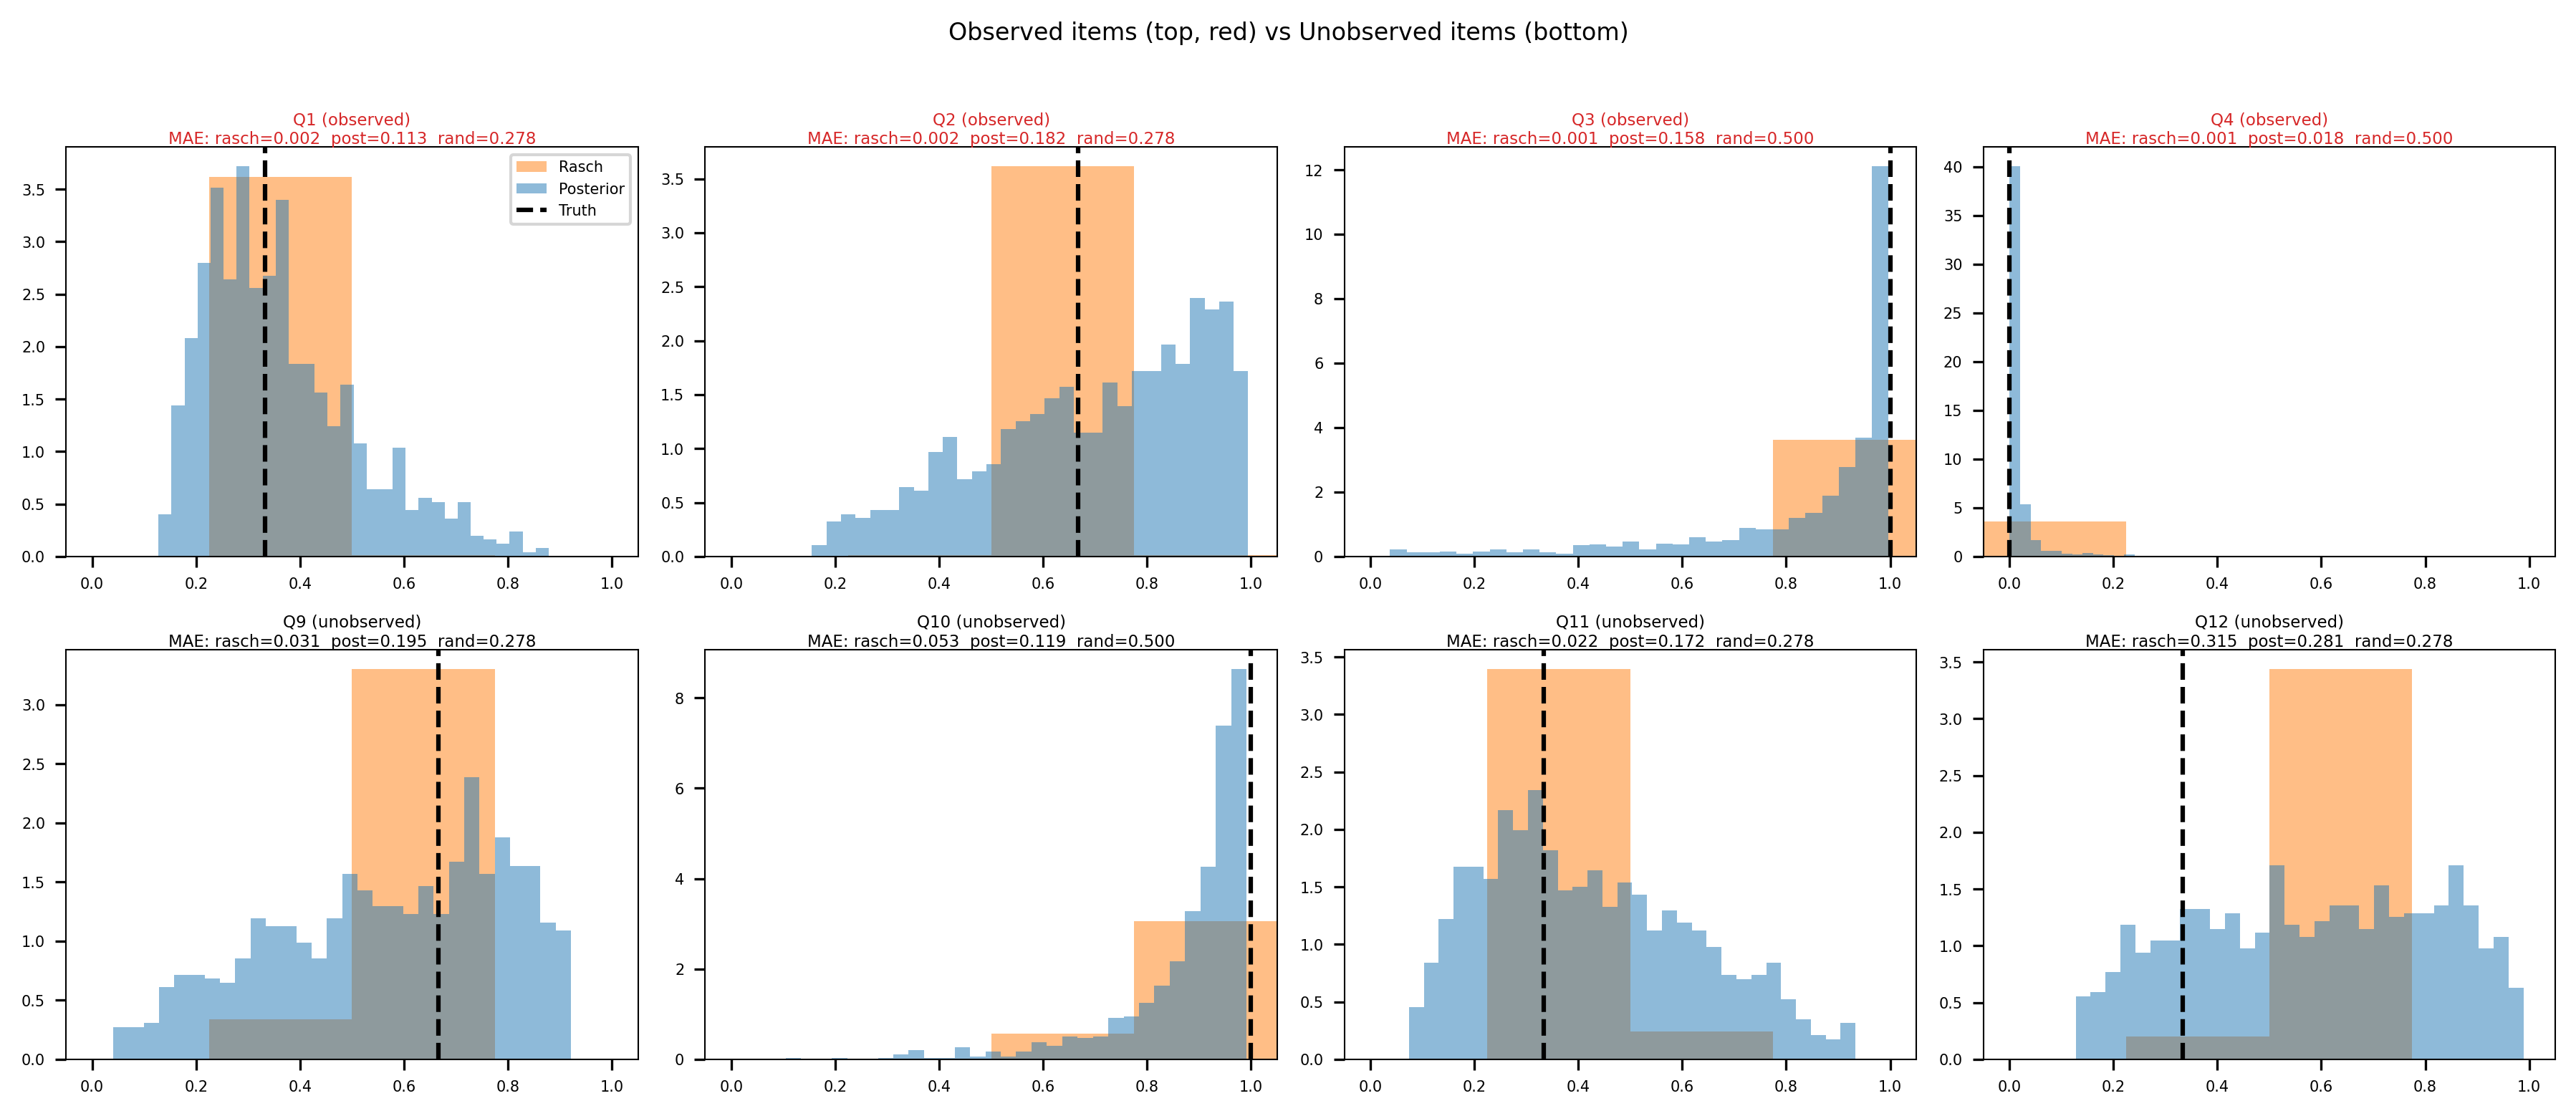

In [19]:
# Compare histograms: 4 observed items (top) vs 4 unobserved items (bottom)
# MAE per panel for Rasch, Posterior, and Random baseline
example_observed = list(observed_items[:4])
unobserved_items = [item for item in xplore.items if item not in observed_items]
example_unobserved = unobserved_items[:4]
example_items = example_observed + example_unobserved

# Random baseline expected MAE per item: E[|U - v|] = (v^2 + (1-v)^2) / 2
random_mae_per_item = (true_vals**2 + (1 - true_vals)**2) / 2

fig, axes = plt.subplots(2, 4, figsize=(12, 5))
for ax, item in zip(axes.flat, example_items):
    idx = list(xplore.items).index(item)
    is_obs = item in observed_items
    
    # Rasch: discrete categories
    bin_edges = np.linspace(-0.05, 1.05, num_options + 1)
    ax.hist(rasch_samples[:, idx], bins=bin_edges,
            alpha=0.5, color='tab:orange', density=True, label='Rasch')
    # Posterior: continuous
    ax.hist(posterior_samples[:, idx], bins=30, alpha=0.5, color='tab:blue', 
            density=True, label='Posterior')
    # Ground truth
    ax.axvline(true_vals[idx], color='black', lw=1.5, ls='--', label='Truth')
    
    # Per-item MAE for each method
    mae_r = np.mean(np.abs(rasch_samples[:, idx] - true_vals[idx]))
    mae_p = np.mean(np.abs(posterior_samples[:, idx] - true_vals[idx]))
    mae_rand = random_mae_per_item[idx]
    
    status = "(observed)" if is_obs else "(unobserved)"
    title = (f'{item} {status}\n'
             f'MAE: rasch={mae_r:.3f}  post={mae_p:.3f}  rand={mae_rand:.3f}')
    ax.set_title(title, fontsize=5.5, color='tab:red' if is_obs else 'black')
    ax.set_xlim(-0.05, 1.05)

axes.flat[0].legend(fontsize=5)
fig.suptitle('Observed items (top, red) vs Unobserved items (bottom)',
             fontsize=8, y=1.02)
plt.tight_layout()
plt.show()

ixplore - INFO - 2026-03-14 11:01:48 - MAE: 0.0761, ACC: 0.9654


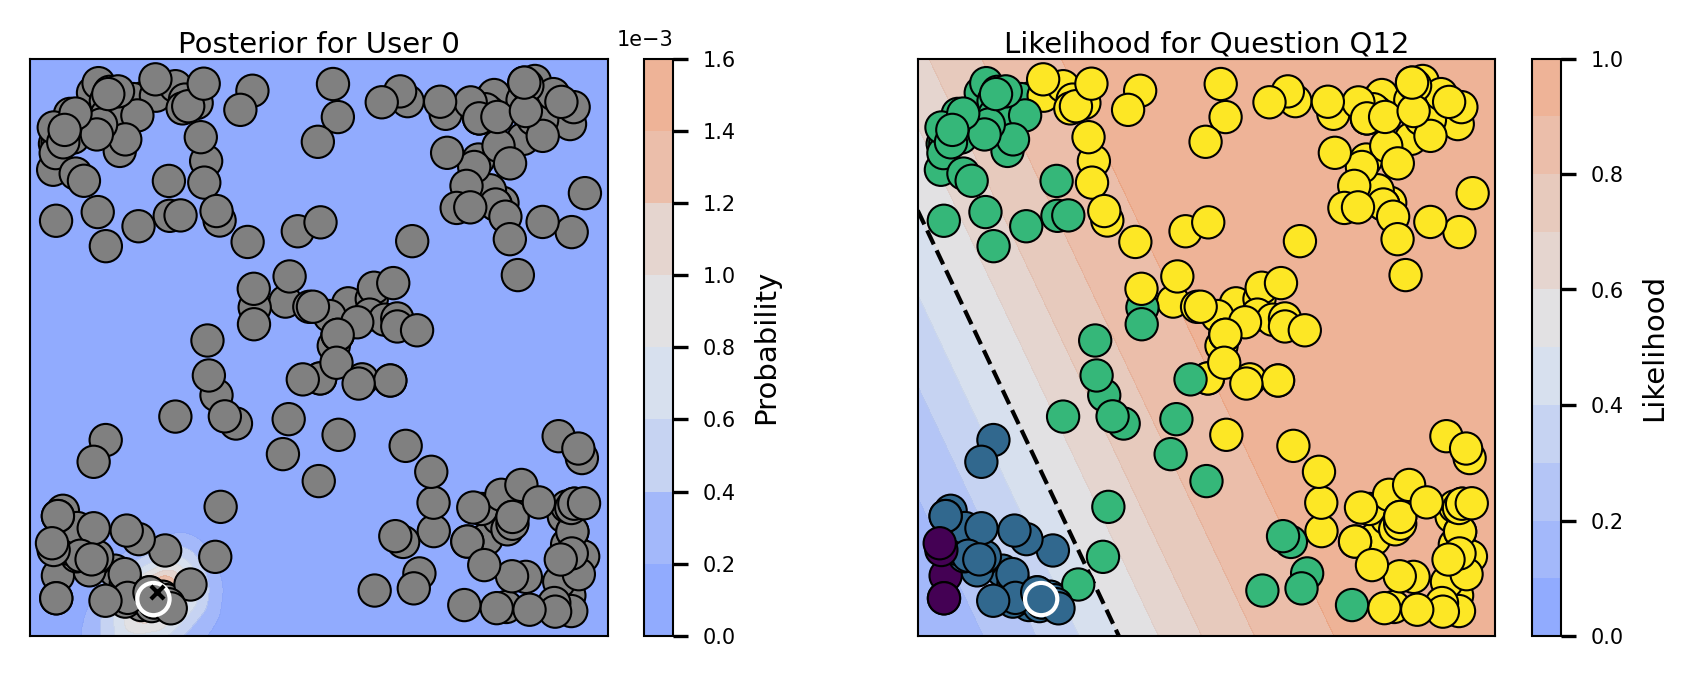

In [21]:
from ixplore.visualization import plot_overview
fig, ax = plot_overview(xplore, question='Q12', user='0', figsize=(7,2.5))

## 5. Effect of Number of Observed Answers

How does prediction quality change as we observe more answers from the new user?

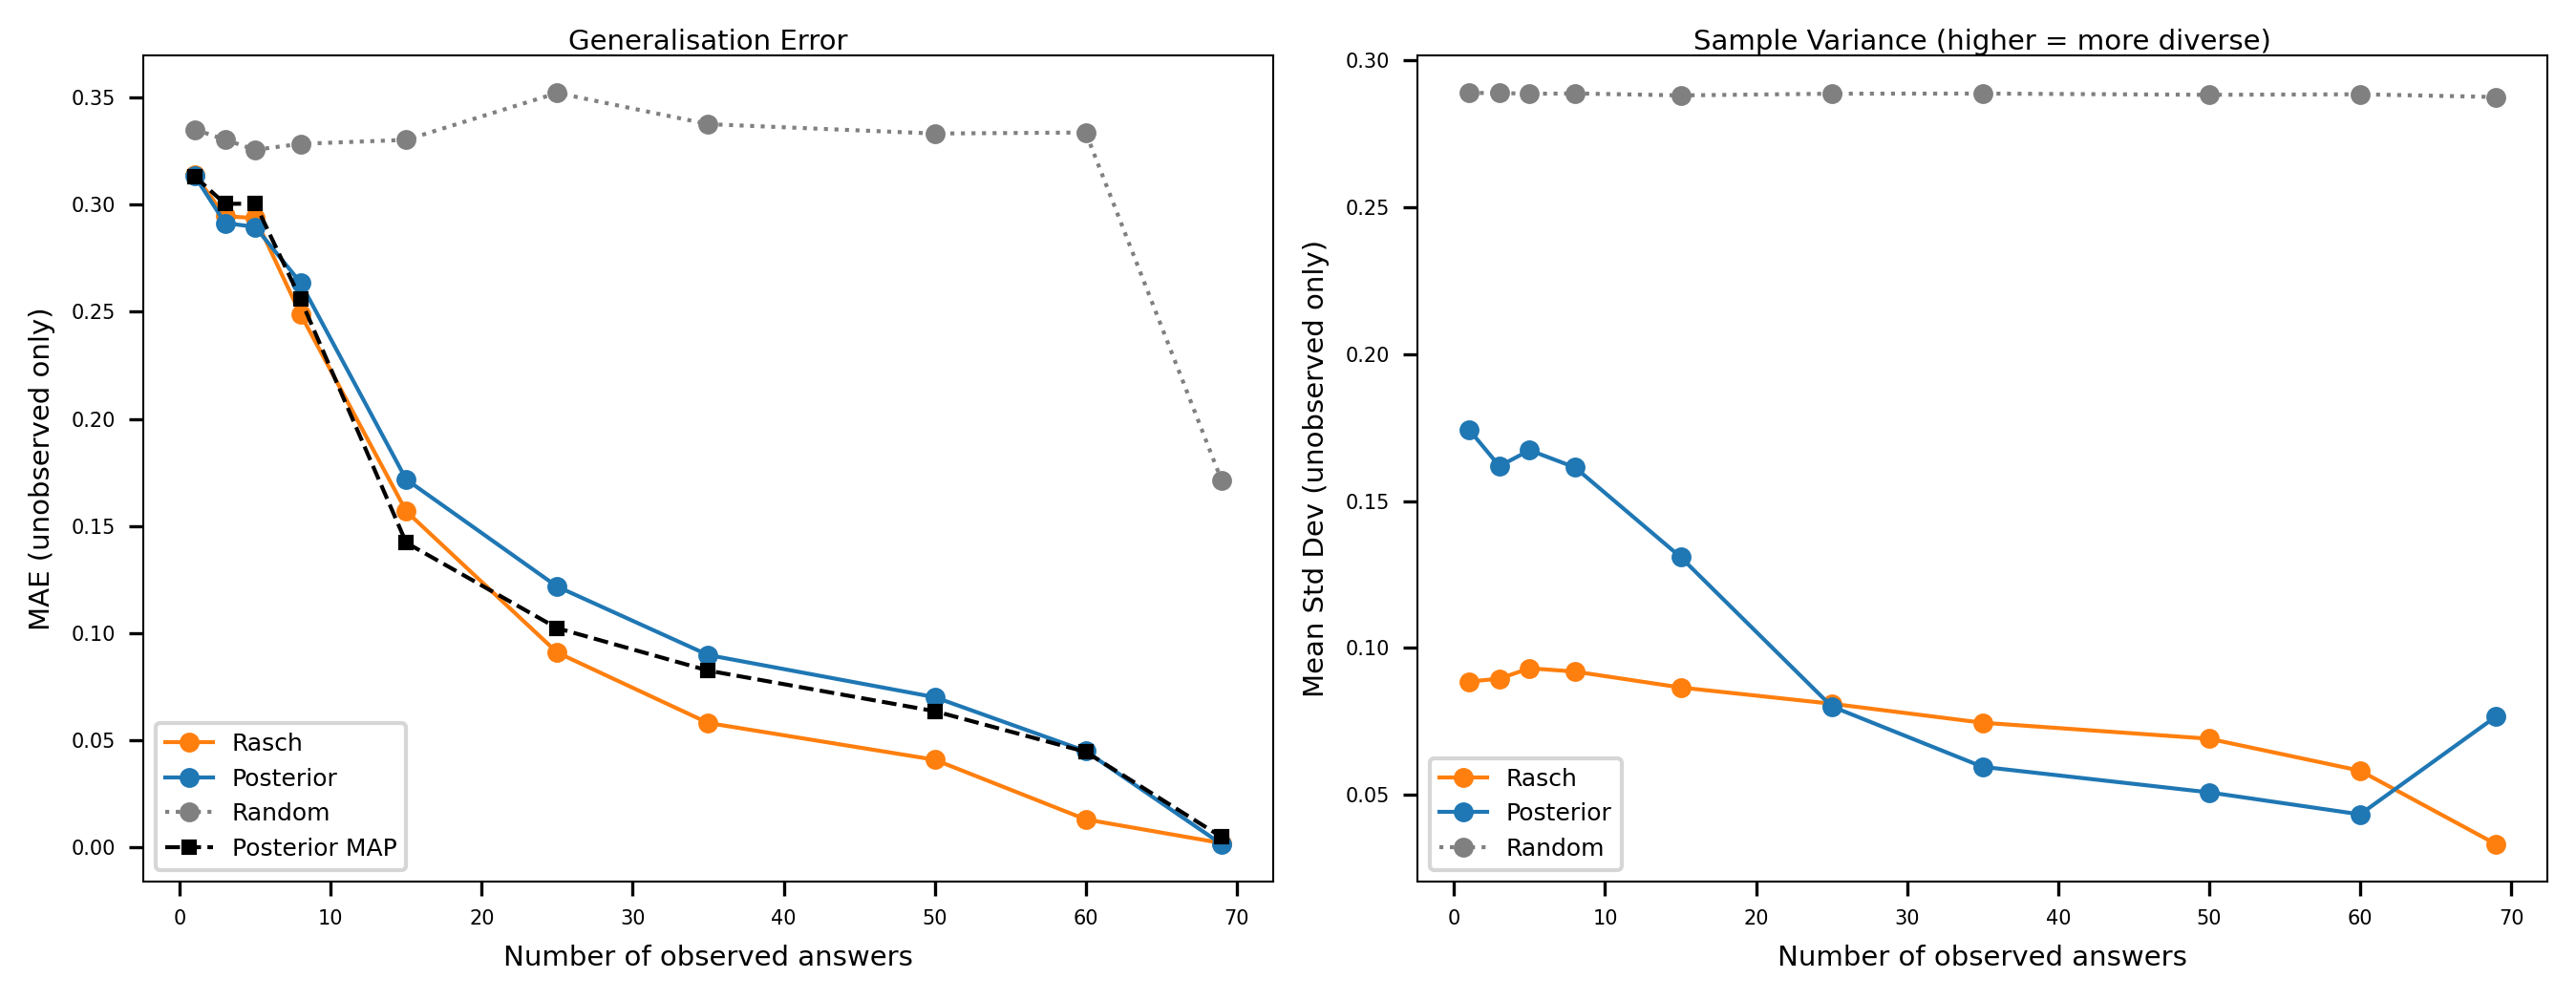

In [ ]:
# Sweep over the full range of observed answers
# MAE and variance are computed only on unobserved items
n_obs_values = [1, 3, 5, 8, 15, 25, 35, 50, 60, 69]
all_items = list(xplore.items)
rng_sweep = np.random.default_rng(42)
item_order = rng_sweep.permutation(all_items)

results = {'n_obs': [], 'method': [], 'mae': [], 'mean_std': []}
map_maes = []  # MAP point-estimate MAE for reference

for n in n_obs_values:
    obs = item_order[:n]
    pa = true_answers_scaled[obs]
    unobs = np.array([item not in obs for item in xplore.items])
    
    # MAP prediction: embed user, predict from single point
    map_pos = xplore.embed_new_user(pa)
    map_pred = xplore.predict(map_pos.reshape(1, -1))[0]
    map_maes.append(np.mean(np.abs(map_pred[unobs] - true_vals[unobs])))
    
    for method, label in [('rasch', 'Rasch'), ('posterior', 'Posterior'), ('random', 'Random')]:
        kwargs = dict(method=method, num_samples=500)
        if method == 'rasch':
            kwargs.update(num_options=num_options, variance=variance)
        samples = xplore.sample_pseudo_answers(pa, **kwargs)
        
        # For random: use many more samples for a stable estimate
        if method == 'random':
            samples_large = xplore.sample_pseudo_answers(pa, method='random', num_samples=5000)
            mae = np.mean(np.abs(samples_large[:, unobs].mean(axis=0) - true_vals[unobs]))
            std = samples_large[:, unobs].std(axis=0).mean()
        else:
            mae = np.mean(np.abs(samples[:, unobs].mean(axis=0) - true_vals[unobs]))
            std = samples[:, unobs].std(axis=0).mean()
        
        results['n_obs'].append(n)
        results['method'].append(label)
        results['mae'].append(mae)
        results['mean_std'].append(std)

res_df = pd.DataFrame(results)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5))

for method, color, ls in [('Rasch', 'tab:orange', '-'), ('Posterior', 'tab:blue', '-'), ('Random', 'gray', ':')]:
    subset = res_df[res_df['method'] == method]
    ax1.plot(subset['n_obs'], subset['mae'], marker='o', color=color, label=method, markersize=4, ls=ls)
    ax2.plot(subset['n_obs'], subset['mean_std'], marker='o', color=color, label=method, markersize=4, ls=ls)

# MAP point-estimate MAE as dashed line
ax1.plot(n_obs_values, map_maes, marker='s', color='black', ls='--', lw=1, markersize=3, label='Posterior MAP')

ax1.set(xlabel='Number of observed answers', ylabel='MAE (unobserved only)', title='Generalisation Error')
ax2.set(xlabel='Number of observed answers', ylabel='Mean Std Dev (unobserved only)', title='Sample Variance (higher = more diverse)')
ax1.legend(fontsize=6)
ax2.legend(fontsize=6)
plt.tight_layout()
plt.show()

## 6. Summary & Interpretation

### Metrics are on unobserved items only

All MAE and variance numbers are computed exclusively on **unobserved items**. The figures 
show all items (observed highlighted), but the aggregate metrics reflect only the items 
the model has to predict.

### High accuracy *and* high variance is the goal

The ideal sampler is **accurate on average** (low MAE) while producing **diverse samples** 
(high variance). Low MAE = centred on the right answer. High variance = captures the full 
range of plausible responses, essential for data augmentation, active learning, or ensembles.

### Key differences

| Aspect | Rasch | Posterior | Random |
|--------|-------|----------|--------|
| **Output** | Discrete categories | Continuous [0, 1] | Uniform [0, 1] |
| **Domain** | Answer space (imputed scores) | Latent space (sampled positions) | No model |
| **Variance** | CRF hyperparameter (fixed) | Posterior spread (data-driven) | Maximum entropy |
| **Accuracy vs Variance** | Accurate, low variance | Accurate, high variance | Inaccurate, high variance |

### What the convergence sweep reveals

- **Posterior MAP** (black dashed) shows the deterministic point-estimate baseline — the 
  best single prediction from the model.
- **Posterior sampling** tracks the MAP line closely in MAE but adds substantial variance — 
  the best of both worlds.
- **Rasch sampling** has comparable MAE but lower variance, constrained by discrete categories 
  and peaked CRFs.
- **Random baseline** is flat across all observation counts — it never learns from data.

### When to use which

- **Rasch**: discrete Likert-scale pseudo-answers (data augmentation with realistic responses).
- **Posterior**: accuracy and diversity together — best for active learning, ensembles, or 
  generating realistic distributions of plausible answers.
- **Random**: sanity check only.